# Exercise 1: Box Detection - Computer Vision Project (Summer 2025)

This notebook contains the complete solution to Exercise 1 of the Computer Vision Project course.
---


## Exercise 1.1: Box Detection

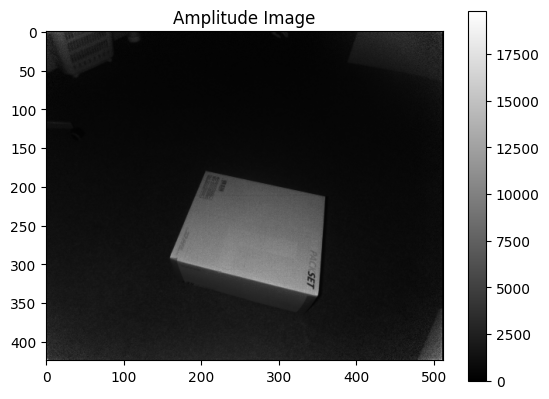

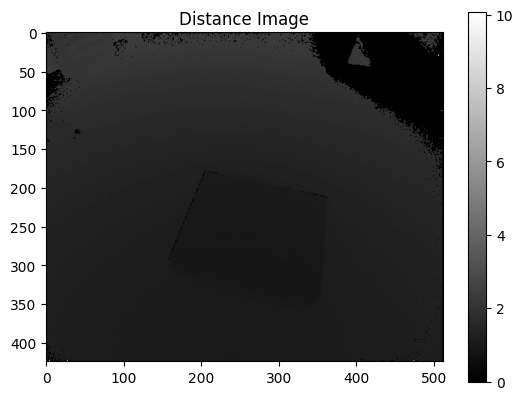

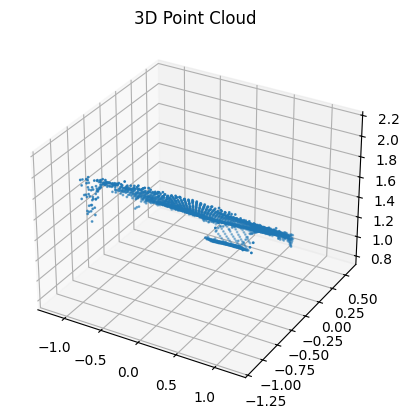

In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load .mat file
data = scipy.io.loadmat('data/example2kinect.mat')

# Extract amplitude, distance, and point cloud
A = data['amplitudes2']
D = data['distances2']
PC = data['cloud2']

# Visualize Amplitude Image
plt.figure()
plt.title("Amplitude Image")
plt.imshow(A, cmap='gray')
plt.colorbar()
plt.show()

# Visualize Distance Image
plt.figure()
plt.title("Distance Image")
plt.imshow(D, cmap='gray')
plt.colorbar()
plt.show()

# Visualize Point Cloud (subsampled)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
step = 10
X, Y, Z = PC[::step, ::step, 0], PC[::step, ::step, 1], PC[::step, ::step, 2]
mask = Z != 0
ax.scatter(X[mask], Y[mask], Z[mask], s=1)
ax.set_title("3D Point Cloud")
plt.show()


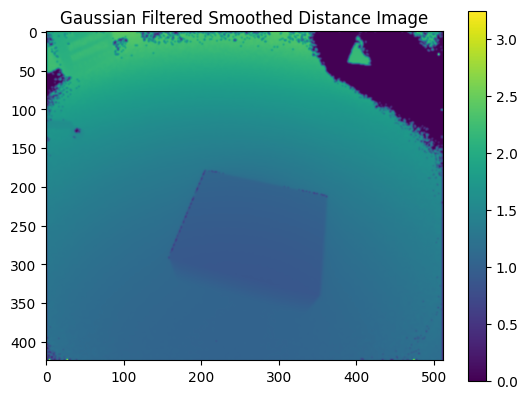

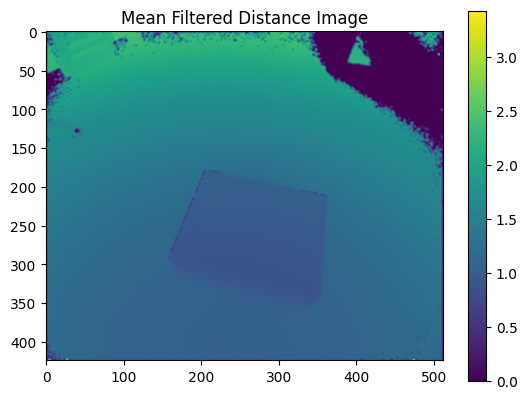

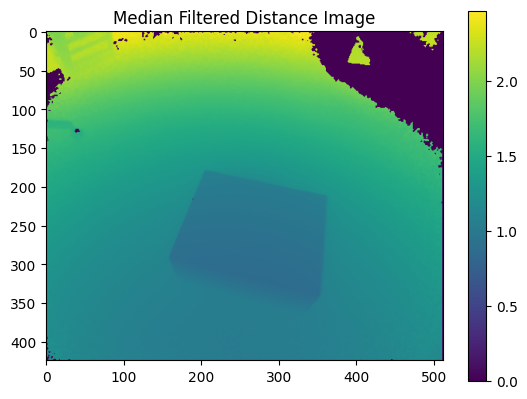

In [2]:
from scipy.ndimage import gaussian_filter

# Apply Gaussian filter to distance image
smoothed_distance = gaussian_filter(D, sigma=1)

plt.title("Gaussian Filtered Smoothed Distance Image")
plt.imshow(smoothed_distance, cmap="viridis")
plt.colorbar()
plt.show()



from scipy.ndimage import convolve

mean_kernel = np.ones((3, 3)) / 9
mean_filtered_distance = convolve(D, mean_kernel)

plt.title("Mean Filtered Distance Image")
plt.imshow(mean_filtered_distance, cmap="viridis")
plt.colorbar()
plt.show()


from scipy.ndimage import median_filter

median_filtered_distance = median_filter(D, size=3)

plt.title("Median Filtered Distance Image")
plt.imshow(median_filtered_distance, cmap="viridis")
plt.colorbar()
plt.show()

In [3]:
import random
random.seed(42)
np.random.seed(42)

# Fit a plane from three points using the cross product
def fit_plane(p1, p2, p3):
    v1 = p2 - p1
    v2 = p3 - p1
    normal = np.cross(v1, v2)
    norm = np.linalg.norm(normal)
    if norm == 0:
        raise ValueError("Degenerate normal vector (points may be co-linear)")
    normal /= norm
    d = np.dot(normal, p1)
    return normal, d

# Compute inliers that lie close to the plane
def compute_inliers(points, normal, d, threshold):
    mask_valid = points[:, 2] != 0
    filtered_points = points[mask_valid]
    distances = np.abs(filtered_points @ normal - d)
    inlier_mask = distances < threshold
    inlier_indices = np.where(mask_valid)[0][inlier_mask]
    return inlier_indices, distances

# RANSAC loop to find the best-fitting plane
def ransac_plane(points, threshold=0.02, max_iter=500):
    best_inliers = []
    best_model = (None, None)
    for _ in range(max_iter):
        sample_indices = random.sample(range(points.shape[0]), 3)
        selected_points = points[sample_indices]

        # Skip if points are co-linear
        if np.linalg.matrix_rank(selected_points - selected_points[0]) < 2:
            continue

        try:
            normal, d = fit_plane(*selected_points)
        except Exception:
            continue

        inliers, _ = compute_inliers(points, normal, d, threshold)

        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (normal, d)
    return best_model, best_inliers


Threshold: 0.0020, Inliers: 40655
Threshold: 0.0050, Inliers: 83519
Threshold: 0.0100, Inliers: 123131
Threshold: 0.0150, Inliers: 143252
Threshold: 0.0200, Inliers: 152860
Threshold: 0.0300, Inliers: 162107
Threshold: 0.0400, Inliers: 165674
Threshold: 0.0500, Inliers: 167556


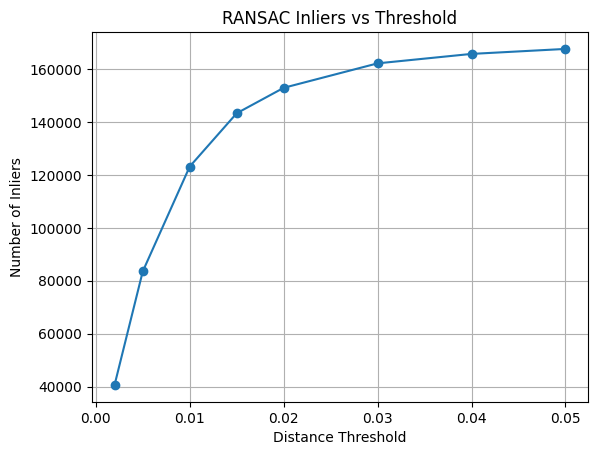

In [4]:
import matplotlib.pyplot as plt

# Hyperparameter tuning for RANSAC threshold
thresholds = [0.002, 0.005, 0.01, 0.015, 0.02, 0.03, 0.04, 0.05]
inlier_counts = []

points = PC.reshape(-1, 3)

for t in thresholds:
    _, inliers = ransac_plane(points, threshold=t, max_iter=500)
    inlier_counts.append(len(inliers))
    print(f"Threshold: {t:.4f}, Inliers: {len(inliers)}")

# Elbow plot
plt.figure()
plt.plot(thresholds, inlier_counts, marker='o')
plt.title("RANSAC Inliers vs Threshold")
plt.xlabel("Distance Threshold")
plt.ylabel("Number of Inliers")
plt.grid(True)
plt.show()

### Based on the elbow plot, the optimal threshold for RANSAC is around 0.02. It provides a high number of inliers while avoiding the diminishing returns and noise from higher thresholds like 0.04 or 0.05.

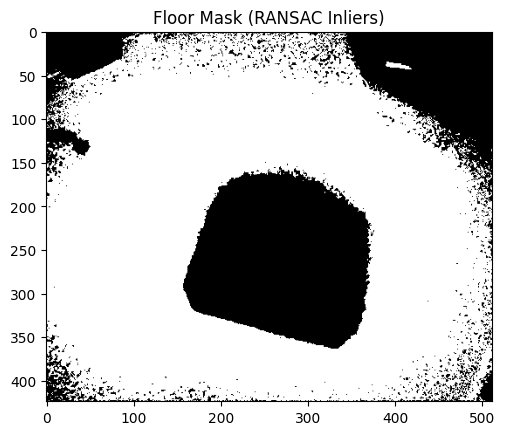

In [5]:
# Flatten and run RANSAC
H, W, _ = PC.shape
points = PC.reshape(-1, 3)
plane_model, inlier_indices = ransac_plane(points)

# Create floor mask
floor_mask = np.zeros(H * W, dtype=np.uint8)
floor_mask[inlier_indices] = 1
floor_mask = floor_mask.reshape(H, W)

# Show floor mask
plt.figure()
plt.title("Floor Mask (RANSAC Inliers)")
plt.imshow(floor_mask, cmap='gray')
plt.show()


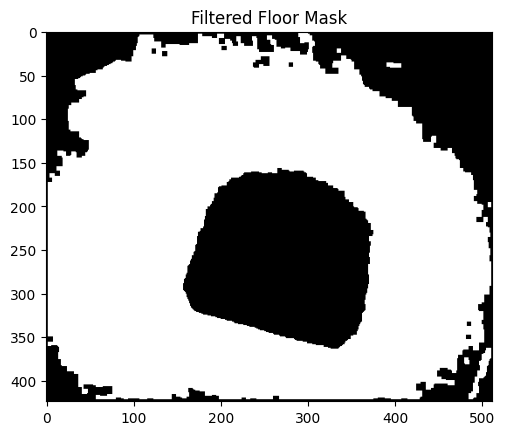

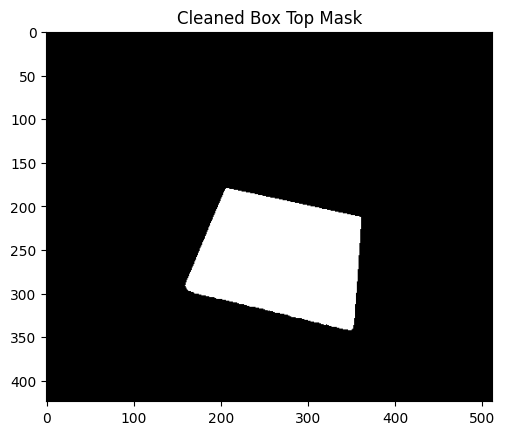

In [6]:
from scipy.ndimage import binary_opening, binary_closing, label

# Morphological filtering
structuring_element = np.ones((5, 5))
opened_mask = binary_opening(floor_mask, structure=structuring_element)
closed_mask = binary_closing(opened_mask, structure=structuring_element)

plt.figure()
plt.title("Filtered Floor Mask")
plt.imshow(closed_mask, cmap='gray')
plt.show()

# Filter points 5–30 cm above floor
floor_normal, floor_d = plane_model
all_points = PC.reshape(-1, 3)
valid_mask = all_points[:, 2] != 0
filtered_points = all_points[valid_mask]
floor_distances = np.abs(filtered_points @ floor_normal - floor_d)
box_candidates = filtered_points[(floor_distances > 0.05) & (floor_distances < 0.3)]

# RANSAC for box top
top_model, top_inlier_indices = ransac_plane(box_candidates)
top_inlier_points = box_candidates[top_inlier_indices]

# Project to image
box_top_mask = np.zeros_like(closed_mask, dtype=np.uint8)
for point in top_inlier_points:
    diff = np.linalg.norm(PC - point.reshape(1, 1, 3), axis=2)
    i, j = np.unravel_index(np.argmin(diff), diff.shape)
    box_top_mask[i, j] = 1

# Largest component
labeled_mask, _ = label(box_top_mask)
sizes = np.bincount(labeled_mask.ravel())
sizes[0] = 0
largest_label = sizes.argmax()
box_top_mask_cleaned = (labeled_mask == largest_label)

plt.figure()
plt.title("Cleaned Box Top Mask")
plt.imshow(box_top_mask_cleaned, cmap='gray')
plt.show()


In [7]:
# Height between planes
top_normal, top_d = top_model
height = abs(floor_d - top_d)
print(f"Box Height (m): {height:.4f}")

# Get 3D points from box top mask
box_top_points = PC[box_top_mask_cleaned]
box_top_points = box_top_points[box_top_points[:, 2] != 0]

# Bounding box
min_corner = box_top_points.min(axis=0)
max_corner = box_top_points.max(axis=0)
length = np.linalg.norm(max_corner[[0,1]] - min_corner[[0,1]])
width  = abs(max_corner[0] - min_corner[0])
depth  = abs(max_corner[1] - min_corner[1])

print(f"Box Length (XY diagonal): {length:.4f} m")
print(f"Box Width (X): {width:.4f} m")
print(f"Box Depth (Y): {depth:.4f} m")


Box Height (m): 1.8367
Box Length (XY diagonal): 0.6449 m
Box Width (X): 0.5251 m
Box Depth (Y): 0.3744 m


## Exercise 1.2: Discussion – Box Detection

In this exercise, we implemented a Python pipeline to estimate the 3D dimensions of a box from Time-of-Flight (ToF) data. The `.mat` file included a registered amplitude image, distance image, and point cloud.

We visualized the amplitude and distance images using `matplotlib`, and displayed the point cloud in 3D using a subsampled `scatter3D`. To estimate the height of the box, we used our own RANSAC implementation (not from scikit-learn) to detect two planes: the floor and the top surface of the box.

We filtered the point cloud to remove invalid (z=0) data and optimized performance by using NumPy functions like `dot`, `cross`, and `where` rather than explicit loops. Morphological operations (binary opening and closing) were applied to clean the RANSAC masks, and `scipy.ndimage.label` was used to extract the largest connected component on the top surface, which is assumed to be the box.

Finally, we computed:
- **Box height:** from the distance between the two planes
- **Box length/width:** from the axis-aligned bounding box of the 3D points

### Limitations & Suggestions:
- The method is sensitive to noise and heavily depends on good RANSAC parameters (e.g., threshold, max iterations).
- Better results could be achieved using adaptive thresholding, region growing, or fitting with more advanced segmentation methods.
- Edge-based detection of box contours could improve length/width estimation accuracy.
